<a href="https://colab.research.google.com/github/anuraganupam02-rgb/DocuMed/blob/main/Copy_of_Yarrowia_Biomass_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/yarrowia_biomass_project_dataset_100.csv')

df.head()

,Experiment_ID,Time_h,Temperature_C,Shaking_rate_rpm,Inoculum_size_cells_per_mL,pH,Crude_glycerol_pct,Ammonium_sulfate_g_L,Yeast_extract_g_L,Biomass_g_L,Reference_year
0,1,0.0,30.0,140.0,100000000.0,6.0,10.0,0.000000,0.0,0.0,2013.0
1,2,0.0,30.0,140.0,100000000.0,6.0,8.0,0.000000,0.0,0.0,2013.0
2,3,0.0,30.0,140.0,100000000.0,6.0,0.0,4.761905,0.0,0.0,2013.0
3,4,0.0,30.0,140.0,100000000.0,6.0,0.0,0.000000,10.0,0.0,2013.0
4,5,12.0,30.0,140.0,100000000.0,6.0,0.0,0.000000,10.0,0.8,2013.0


In [ ]:
print("Number of experiments:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of experiments: 100
Number of columns: 11

Column names:
['Experiment_ID', 'Time_h', 'Temperature_C', 'Shaking_rate_rpm', 'Inoculum_size_cells_per_mL', 'pH', 'Crude_glycerol_pct', 'Ammonium_sulfate_g_L', 'Yeast_extract_g_L', 'Biomass_g_L', 'Reference_year']


In [ ]:
for column in df.columns:
      print(column)

Experiment_ID
Time_h
Temperature_C
Shaking_rate_rpm
Inoculum_size_cells_per_mL
pH
Crude_glycerol_pct
Ammonium_sulfate_g_L
Yeast_extract_g_L
Biomass_g_L
Reference_year


In [ ]:
df.describe().round(2)

,Experiment_ID,Time_h,Temperature_C,Shaking_rate_rpm,Inoculum_size_cells_per_mL,pH,Crude_glycerol_pct,Ammonium_sulfate_g_L,Yeast_extract_g_L,Biomass_g_L,Reference_year
count,100.00,100.00,100.00,100.00,1.000000e+02,100.00,100.00,100.00,100.00,100.00,100.00
mean,50.50,37.53,29.86,142.80,1.087000e+08,5.93,1.95,0.88,0.72,3.55,2016.47
std,29.01,26.97,0.51,10.26,4.096451e+07,0.36,2.63,1.75,2.90,3.31,2.97
min,1.00,0.00,28.00,140.00,1.000000e+07,4.30,0.00,0.00,0.00,0.00,2013.00
25%,25.75,12.00,30.00,140.00,1.000000e+08,6.00,0.00,0.00,0.00,2.04,2013.00
50%,50.50,36.00,30.00,140.00,1.000000e+08,6.00,1.24,0.00,0.00,3.32,2016.00
75%,75.25,60.00,30.00,140.00,1.000000e+08,6.00,2.11,0.12,0.00,4.00,2020.00
max,100.00,120.00,30.00,180.00,2.500000e+08,6.50,10.00,4.76,15.00,22.00,2020.00


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Experiment_ID                 0
Time_h                        0
Temperature_C                 0
Shaking_rate_rpm              0
Inoculum_size_cells_per_mL    0
pH                            0
Crude_glycerol_pct            0
Ammonium_sulfate_g_L          0
Yeast_extract_g_L             0
Biomass_g_L                   0
Reference_year                0
dtype: int64


In [ ]:
model_columns = ['Time_h', 'Temperature_C', 'Shaking_rate_rpm',
                 'Inoculum_size_cells_per_mL', 'pH',
                 'Crude_glycerol_pct', 'Ammonium_sulfate_g_L',
                 'Yeast_extract_g_L', 'Biomass_g_L']

print("Duplicate observations:", df.duplicated(subset=model_columns).sum())
print("Minimum biomass:", df['Biomass_g_L'].min())
print("Maximum biomass:", df['Biomass_g_L'].max())

for col in model_columns:
    print(col, df[col].nunique())

Duplicate observations: 1
Minimum biomass: 0.0
Maximum biomass: 22.0
Time_h 9
Temperature_C 2
Shaking_rate_rpm 2
Inoculum_size_cells_per_mL 3
pH 5
Crude_glycerol_pct 18
Ammonium_sulfate_g_L 4
Yeast_extract_g_L 4
Biomass_g_L 75


In [ ]:
dup = df[df.duplicated(subset=model_columns, keep=False)]

dup

,Experiment_ID,Time_h,Temperature_C,Shaking_rate_rpm,Inoculum_size_cells_per_mL,pH,Crude_glycerol_pct,Ammonium_sulfate_g_L,Yeast_extract_g_L,Biomass_g_L,Reference_year
2,3,0.0,30.0,140.0,100000000.0,6.0,0.0,4.761905,0.0,0.0,2013.0
35,36,0.0,30.0,140.0,100000000.0,6.0,0.0,4.761905,0.0,0.0,2016.0


In [ ]:
dup.T

,2,35
Experiment_ID,3.000000e+00,3.600000e+01
Time_h,0.000000e+00,0.000000e+00
Temperature_C,3.000000e+01,3.000000e+01
Shaking_rate_rpm,1.400000e+02,1.400000e+02
Inoculum_size_cells_per_mL,1.000000e+08,1.000000e+08
pH,6.000000e+00,6.000000e+00
Crude_glycerol_pct,0.000000e+00,0.000000e+00
Ammonium_sulfate_g_L,4.761905e+00,4.761905e+00
Yeast_extract_g_L,0.000000e+00,0.000000e+00
Biomass_g_L,0.000000e+00,0.000000e+00


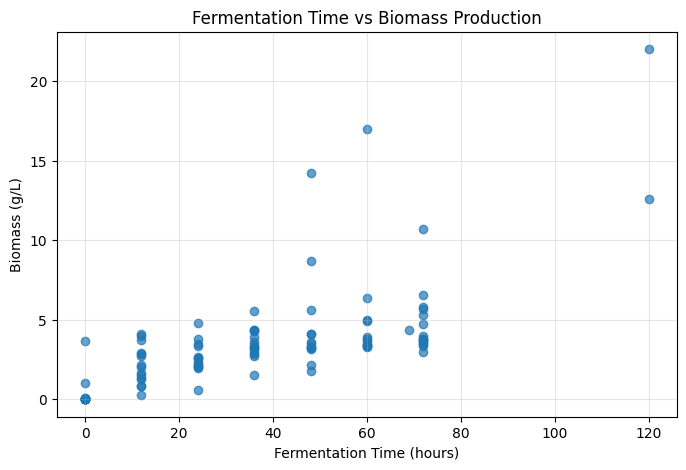

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Time_h'], df['Biomass_g_L'], alpha=0.7)

plt.xlabel('Fermentation Time (hours)')
plt.ylabel('Biomass (g/L)')
plt.title('Fermentation Time vs Biomass Production')

plt.grid(alpha=0.3)
plt.show()

In [ ]:
predictors = [
    'Time_h',
    'Temperature_C',
    'Shaking_rate_rpm',
    'Inoculum_size_cells_per_mL',
    'pH',
    'Crude_glycerol_pct',
    'Ammonium_sulfate_g_L',
    'Yeast_extract_g_L'
]

correlations = df[predictors + ['Biomass_g_L']].corr()['Biomass_g_L']
correlations = correlations.drop('Biomass_g_L').sort_values(ascending=False)

print("Correlation with biomass:")
print(correlations.round(3))

Correlation with biomass:
Shaking_rate_rpm              0.730
Inoculum_size_cells_per_mL    0.708
Time_h                        0.665
pH                            0.237
Ammonium_sulfate_g_L          0.086
Crude_glycerol_pct            0.037
Yeast_extract_g_L            -0.094
Temperature_C                -0.730
Name: Biomass_g_L, dtype: float64


In [ ]:
print(df.groupby(['Temperature_C', 'Shaking_rate_rpm']).size())

print("\nTemperature vs inoculum combinations:")
print(df.groupby(['Temperature_C', 'Inoculum_size_cells_per_mL']).size())

Temperature_C  Shaking_rate_rpm
28.0           180.0                7
30.0           140.0               93
dtype: int64

Temperature vs inoculum combinations:
Temperature_C  Inoculum_size_cells_per_mL
28.0           250000000.0                    7
30.0           10000000.0                     2
               100000000.0                   91
dtype: int64


In [ ]:
df = pd.read_csv('/content/yarrowia_biomass_project_dataset_100_v2.csv')

print("Number of experiments:", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of experiments: 100
Number of columns: 12


,Experiment_ID,Source_TableS1_Row,Time_h,pH,COD_g_L,Glucose_g_L,Crude_glycerol_pct,Ammonium_sulfate_g_L,Yeast_extract_g_L,Total_nitrogen_g_L,Biomass_g_L,Reference_year
0,1,58,0,6.0,37.000,0,0.0,0.0,0,0.103,0.00,2013
1,2,60,24,6.0,37.000,0,0.0,0.0,0,0.103,2.13,2013
2,3,62,48,6.0,37.000,0,0.0,0.0,0,0.103,3.60,2013
3,4,64,72,6.0,37.000,0,0.0,0.0,0,0.103,3.46,2013
4,5,69,12,6.0,12.403,0,0.0,0.0,0,0.103,1.13,2013


In [ ]:
ml_columns = [
    'Time_h',
    'pH',
    'COD_g_L',
    'Glucose_g_L',
    'Crude_glycerol_pct',
    'Ammonium_sulfate_g_L',
    'Yeast_extract_g_L',
    'Total_nitrogen_g_L'
]

print("Missing values:", df.isnull().sum().sum())

print("Duplicate ML observations:",
      df.duplicated(subset=ml_columns + ['Biomass_g_L']).sum())

print("\nUnique values:")
for col in ml_columns:
    print(col, ":", df[col].nunique())

print("\nBiomass:")
print("Minimum:", df['Biomass_g_L'].min(), "g/L")
print("Maximum:", df['Biomass_g_L'].max(), "g/L")
print("Unique values:", df['Biomass_g_L'].nunique())

print("\nCorrelation with biomass:")
print(
    df[ml_columns + ['Biomass_g_L']]
    .corr()['Biomass_g_L']
    .drop('Biomass_g_L')
    .sort_values(ascending=False)
    .round(3)
)

Missing values: 0
Duplicate ML observations: 0

Unique values:
Time_h : 7
pH : 4
COD_g_L : 18
Glucose_g_L : 2
Crude_glycerol_pct : 12
Ammonium_sulfate_g_L : 3
Yeast_extract_g_L : 3
Total_nitrogen_g_L : 7

Biomass:
Minimum: 0.0 g/L
Maximum: 8.65 g/L
Unique values: 79

Correlation with biomass:
Time_h                  0.787
Glucose_g_L             0.240
Ammonium_sulfate_g_L    0.228
Yeast_extract_g_L       0.212
Total_nitrogen_g_L     -0.062
COD_g_L                -0.139
Crude_glycerol_pct     -0.155
pH                     -0.290
Name: Biomass_g_L, dtype: float64
